**Enable DRIVE**

In [ ]:
try:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=False)

    print("Google Drive is mounted correctly")

except ModuleNotFoundError:

    print("Local environment detected (not Colab)")

Mounted at /content/drive
Google Drive is mounted correctly


**Read the files**

In [ ]:


import os
import pandas as pd
import matplotlib.pyplot as plt

"""
The `route_files` variable specifies the location of the file,
and `files` is a list containing the file names.
For this to work properly, the files must be in `.txt` format and have sequential numbers.
The range is defined based on the number of files you have:
For example, if you have name1.txt ... name10.txt, then the range would be
range(1,11) because it starts at 1 and ends at 10, since the 11th file is not read.

"""

route_files = "/content/drive/MyDrive/Doctorado/Proyecto_ICF/reduccion colorante con aunps papalo 24 01 2025-20260513T215036Z-3-001/"



def extract_data(name_files):
    with open(name_files, 'r', encoding='latin1') as f:
        lines = f.readlines()

    start = None
    for i, linea in enumerate(lines):
        if "Data Points" in linea:
            start = i + 2
            break
    if start is None:
        raise ValueError(f"No ‘Data Points’ were found in {name_files}")

    df = pd.read_csv(
        name_files,
        sep="\t",
        skiprows=start,
        names=["nm", "Abs"],
        encoding='latin1'
    )

    df = df.dropna()
    df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
    df["Abs"] = pd.to_numeric(df["Abs"], errors="coerce")
    df = df.dropna()

    return df

files = [f"REDU COL. R +  H2O + NaBH4 + AuNPs PAPALO  {i}.TXT" for i in range(1,9)]
files = [route_files + f for f in files]

# Check availability
for a in files:
    if not os.path.exists(a):
        print(f"⚠️ File not found: {a}")
    else:
        extract_data(a).to_csv(
            route_files + os.path.splitext(os.path.basename(a))[0] + "_clean.txt",
            sep="\t",
            index=False
        )

**PLOT**

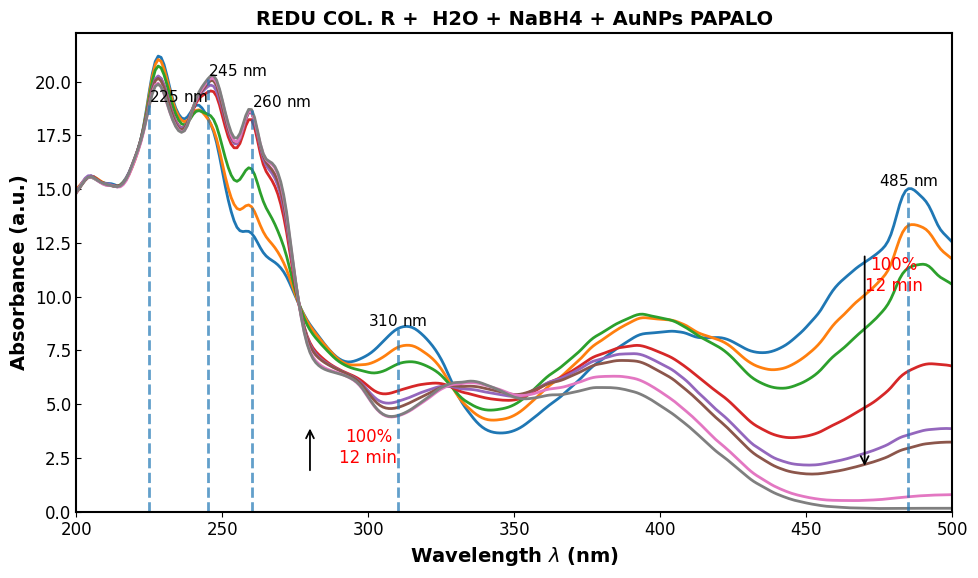


 TABLE 1 (Abs a 485 nm):
    X    Abs_485
0   0  15.021284
1   2  13.310892
2   4  11.332430
3   6   6.538558
4   8   3.576404
5  10   2.955178
6  12   0.694298
7  14   0.152312


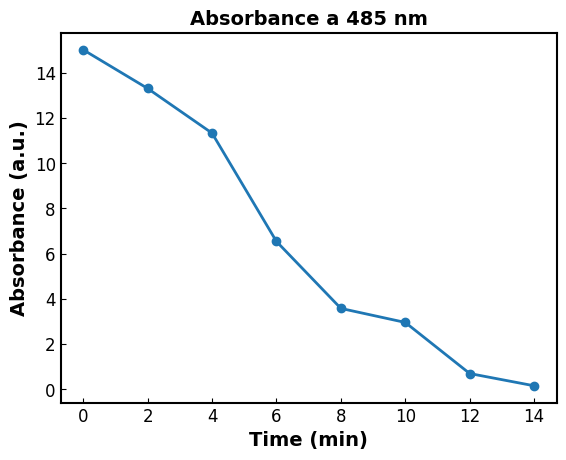


 TABLE 2 (Normalize):
    X  Abs_norm
0   0  1.000000
1   2  0.886135
2   4  0.754425
3   6  0.435286
4   8  0.238089
5  10  0.196733
6  12  0.046221
7  14  0.010140


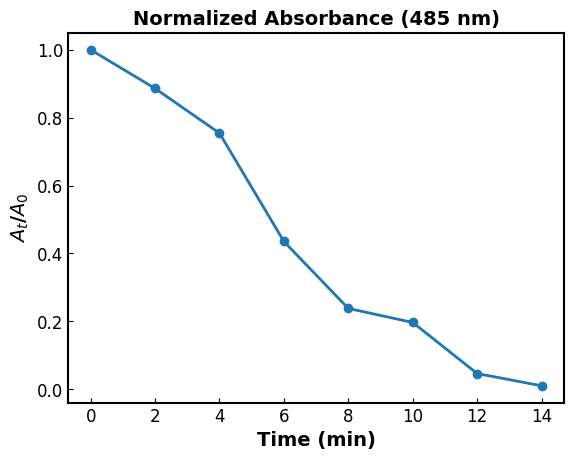


TABLE 3 (Log):
    X  ln(Abs_norm)
0   0      0.000000
1   2     -0.120886
2   4     -0.281800
3   6     -0.831752
4   8     -1.435110
5  10     -1.625909
6  12     -3.074322
7  14     -4.591293


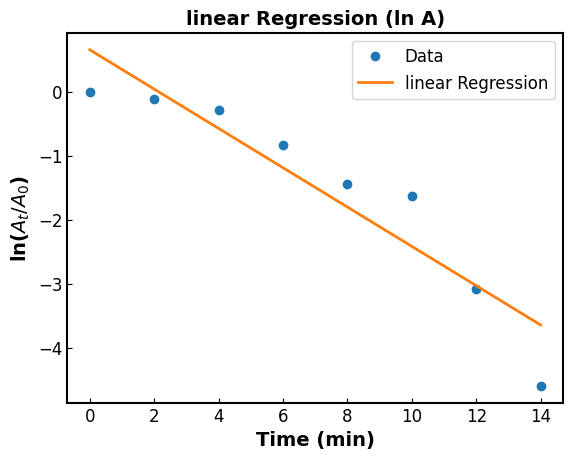

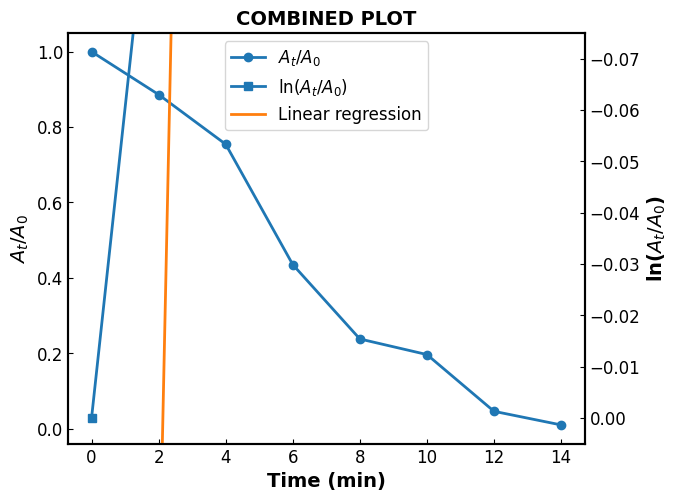


slope: -0.306797
Standard error slope: 0.048017

IC 95% slope:
[-0.424290, -0.189304]

Intercept: 0.652446
Standard error intercept: 0.401738

R²: 0.8719

Constant speed k: 0.306797

IC 95% to k:
[0.189304, 0.424290]

 Efficiency to 485 nm: 98.99%

 k′ = k/m = 311469.180768 (units of k y m)
 Qt = 9812.012310 g/g

ΔG‡ = 86.0980 kJ/mol
Standard error ΔG‡ = ±0.3880 kJ/mol

IC 95% ΔG‡:
[85.1487, 87.0473] kJ/mol

 TON y TOF
Mass of the pollutant after degradation = 0.000643 g
Moles of degraded pollutant = 9.696103e-07 mol
Moles of catalyst = 5.000762e-09 mol

 TON = 193.892533
 TOF = 13.849467 min^-1


In [ ]:
plt.figure(figsize=(10, 6))

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.5,
    "lines.linewidth": 2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# =====================================================
# EXPERIMENTAL DATA (ADJUST ACCORDING TO YOUR EXPERIMENT)
# =====================================================

m = 0.000000985   # catalyst mass (g)
M = 0.00065    # mass of the organic contaminant (g)

molar_mass_catalyst = 196.97   # g/mol (example: Ag = 107.87, Au = 196.97)
molar_mass_contaminant = 663.575  # g/mol (example: 4-NP ≈ 139.11 g/mol)

T = 298.15  # temperature K

# Physical constants
kb = 1.380649e-23   # Boltzmann's constant (J/K)
h = 6.62607015e-34  # Planck's constant (J·s)
R = 8.314           # Gas constant (J/mol·K)

####### Data for the graphs #################################

#######  lines in the UV-VIS spectrum ##############################
val_first = [ 310, 485 ]   # relative to the first curve
val_last = [225,245, 260]    # relative to the last curve

####### wavelength (nm) at which the statistical analysis will be performed########

lambda_target = 485   # CHANGE THE WAVELENGTH (nm) HERE

##############################################################################
### UV-VIS spectrum
##############################################################################

y_first = {}
y_last = {}

for i, file in enumerate(files):
    df = extract_data(file)

    plt.plot(
        df["nm"],
        df["Abs"],
        label=rf"$\mathrm{{4NP}}_{{{i+1}}}$"
   )


    if i == 0:
        for x_nm in val_first:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_first[x_nm] = y_nm


    if i == len(files) - 1:
        for x_nm in val_last:
            y_nm = df.loc[(df["nm"] - x_nm).abs().idxmin(), "Abs"]
            y_last[x_nm] = y_nm



for x_nm, y_nm in y_first.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='center',
             va='bottom')

for x_nm, y_nm in y_last.items():
    plt.vlines(x_nm, 0, y_nm, linestyles='dashed', alpha=0.7)
    plt.text(x_nm, y_nm,
             rf'${x_nm}\ \mathrm{{nm}}$',
             fontsize=11,
             ha='left',
             va='bottom')

########################################################################
## LINES AND ARROWS
########################################################################
# Vertical lines
#plt.plot([200, 250], [0, 15], linestyle='dashed' , alpha=0.7)

# Down arrow
plt.annotate(
    '',
    xy=(470, 2),      # full stop (below)
    xytext=(470, 12),  # starting point (top)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# label above the arrow
plt.text(480, 11, "100%\n12 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

# Up arrow
plt.annotate(
    '',
    xy=(280, 4),      # full stop (below)
    xytext=(280, 1.8),  # starting point (top)
    arrowprops=dict(arrowstyle='->', linewidth=1.3, color='black')
)
# label above the arrow
plt.text(300, 3, "100%\n12 min", color='red', fontsize=12, ha='center',
         va='center', linespacing=1.2 )

########################################################################

#plt.grid(alpha=0.3)
#plt.legend()## This is for the labels on each line
plt.xlabel(r'Wavelength $\lambda$ (nm)', fontsize=14)
plt.ylabel(r'Absorbance (a.u.)', fontsize=14)
plt.title(r'REDU COL. R +  H2O + NaBH4 + AuNPs PAPALO', fontsize=14)


# Axis limits
plt.xlim(200, 500)
plt.ylim(0, None)

#ymin, ymax = plt.ylim()
#xmin, xmax = plt.xlim()

#plt.xticks(np.arange(200, 501, 50))
#plt.yticks(np.arange(0, ymax + 1, 2))

plt.tick_params(axis='x', direction='out')


plt.tight_layout()
plt.savefig(route_files + "uv_vis.pdf", dpi=600, bbox_inches='tight')
plt.savefig(route_files + "uv_vis.tif", dpi=600, bbox_inches='tight')
plt.show()



##########################################################################
# Data analysis
##########################################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 1. EXTRACT Abs at variable λ
# =========================

abs_lambda = []

for file in files:
    df = extract_data(file)

    fila = df.iloc[(df["nm"] - lambda_target).abs().argsort()[:1]]
    abs_lambda.append(fila["Abs"].values[0])

x = np.arange(0, 2 * len(abs_lambda), 2)

table1 = pd.DataFrame({
    "X": x,
    f"Abs_{lambda_target}": abs_lambda
})

print(f"\n TABLE 1 (Abs a {lambda_target} nm):")
print(table1)

plt.figure()
plt.plot(x, abs_lambda, marker='o')
plt.title(f"Absorbance a {lambda_target} nm")
plt.xlabel(r'Time (min)', fontsize=14)
plt.ylabel(r'Absorbance (a.u.)')
#plt.grid()
plt.savefig(route_files + "abs.pdf", dpi=600, bbox_inches='tight')
plt.savefig(route_files + "abs.tif", dpi=600, bbox_inches='tight')
plt.show()

# =========================
# 2. NORMALIZE
# =========================

abs0 = abs_lambda[0]
abs_norm = [a / abs0 for a in abs_lambda]

table2 = pd.DataFrame({
    "X": x,
    "Abs_norm": abs_norm
})

print("\n TABLE 2 (Normalize):")
print(table2)

plt.figure()
plt.plot(x, abs_norm, marker='o')
plt.title(f"Normalized Absorbance ({lambda_target} nm)")
plt.xlabel(r'Time (min)')
plt.ylabel(r"$A_t$/$A_0$")
#plt.grid()
plt.savefig(route_files + "normalized.pdf", dpi=600, bbox_inches='tight')
plt.savefig(route_files + "normalized.tif", dpi=600, bbox_inches='tight')
plt.show()




from scipy.stats import linregress, t

# =========================
# 3. LOG + LINEAR REGRESSION
# =========================

# For pseudo-first-order kinetics:
# ln(Ct/C0) = -kt
# Where:
# Ct is the concentration over time
# C0 is the initial concentration
# K is the reaction rate

log_abs = np.log(abs_norm)

# =========================
# LINEAR REGRESSION
# =========================

result = linregress(x, log_abs)

slope = result.slope
intercept = result.intercept
r_value = result.rvalue
stderr_slope = result.stderr
stderr_intercept = result.intercept_stderr

k = -slope

y_fit = slope * x + intercept

r2 = r_value**2

# =========================
# CONFIDENCE INTERVAL 95%
# =========================

n = len(x)
alpha = 0.05

t_crit = t.ppf(1 - alpha/2, df=n-2)

ic_slope = (
    slope - t_crit * stderr_slope,
    slope + t_crit * stderr_slope
)

ic_intercept = (
    intercept - t_crit * stderr_intercept,
    intercept + t_crit * stderr_intercept
)

ic_k = (
    -ic_slope[1],
    -ic_slope[0]
)

# =========================
# TABLE
# =========================

table3 = pd.DataFrame({
    "X": x,
    "ln(Abs_norm)": log_abs
})

print("\nTABLE 3 (Log):")
print(table3)

# =========================
# PLOT
# =========================

plt.figure()

plt.plot(x, log_abs, 'o', label="Data")
plt.plot(x, y_fit, '-', label="linear Regression")

plt.title("linear Regression (ln A)")
plt.xlabel(r'Time (min)')
plt.ylabel(r"ln($A_t/A_0$)")

plt.legend()
# plt.grid()
plt.savefig(route_files + "regression.pdf", dpi=600, bbox_inches='tight')
plt.savefig(route_files + "regression.tif", dpi=600, bbox_inches='tight')
plt.show()

# =========================
# COMBINED PLOT
# =========================

fig, ax1 = plt.subplots(figsize=(7,5))

# ---------------------------------
# LEFT AXIS Y
# NORMALIZE
# ---------------------------------

ax1.plot(x,abs_norm,'o-',label=r"$A_t/A_0$")

ax1.set_xlabel(r"Time (min)")

ax1.set_ylabel(r"$A_t/A_0$")

# MANUAL RANGE X
#ax1.set_xlim(0, 60)

# MANUAL Y LEFT RANGE
#ax1.set_ylim(0, 1.2)

# ---------------------------------
# RIGHT Y AXIS
# LOG + REGRESSION
# ---------------------------------

ax2 = ax1.twinx()

ax2.plot(x,log_abs,'s-',label=r"ln($A_t/A_0$)")

ax2.plot(x,y_fit,'-',label="Linear regression")

ax2.set_ylabel(r"ln($A_t/A_0$)")

# MANUAL Y RIGHT RANGE
ax2.set_ylim(0.005 , -0.075)

# ---------------------------------
# COMBINED lABELS
# ---------------------------------

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2,loc='upper center')

# ---------------------------------
# SAVE
# ---------------------------------

plt.tight_layout()

plt.savefig(route_files + "combined_plot.pdf",
            dpi=600,bbox_inches='tight')

plt.savefig(route_files + "combined_plot.tif",
            dpi=600,bbox_inches='tight')
plt.title('COMBINED PLOT')
plt.show()


# =========================
# RESULTS
# =========================

print(f"\nslope: {slope:.6f}")
print(f"Standard error slope: {stderr_slope:.6f}")

print(f"\nIC 95% slope:")
print(f"[{ic_slope[0]:.6f}, {ic_slope[1]:.6f}]")

print(f"\nIntercept: {intercept:.6f}")
print(f"Standard error intercept: {stderr_intercept:.6f}")

print(f"\nR²: {r2:.4f}")

print(f"\nConstant speed k: {k:.6f}")

print(f"\nIC 95% to k:")
print(f"[{ic_k[0]:.6f}, {ic_k[1]:.6f}]")

# =========================
# 4. EFFICIENCY
# =========================

#Efficiency = C0 - Cf / C0 * 100
# Where:
# Cf is the final concentration
# C0 is the initial concentration

abs_final = abs_lambda[-1]

efficiency = ((abs0 - abs_final) / abs0) * 100

print(f"\n Efficiency to {lambda_target} nm: {efficiency:.2f}%")


# =========================
# 5. Activity parameter (k ′)
# =========================

#activity parameter
# k′ = k / m
# Where:
# m is the mass of the catalyst
# k is the reaction rate

k_prima = k / m

print(f"\n k′ = k/m = {k_prima:.6f} (units of k y m)")

# =========================
# 6. Reduction capacity (Qt)
# =========================

# Qt = (C0 - Cf) × M / m
# Where:
# m is the mass of the catalyst
# M is the mass of the pollutant
# Cf is the final concentration
# C0 is the initial concentration

Qt = (abs0 - abs_final) * M / m

print(f" Qt = {Qt:.6f} g/g")

# =========================
# 7. ΔG‡ (Free activation energy)
# =========================

#    Eyring equation
#    ΔG‡ = RT ln(kB*T / h*k)
# Where:
# T is the temperature in K
# R is the gas constant
# Kb is Boltzmann's constant
# K is the reaction rate
# h is Planck's constant



# Convert k de min^-1 a s^-1
k_seg = k / 60

# Standard error of k
stderr_k = stderr_slope / 60

# =========================
# ΔG‡
# =========================

delta_G = R * T * np.log((kb * T) / (h * k_seg))

# convert a kJ/mol
delta_G_kJ = delta_G / 1000

# =========================
# STANDARD ERROR
# =========================

error_delta_G = (R * T * (stderr_k / k_seg)) / 1000

# =========================
# CONFIDENCE INTERVAL 95%
# =========================

ic_delta_G = (
    delta_G_kJ - t_crit * error_delta_G,
    delta_G_kJ + t_crit * error_delta_G
)

# =========================
# RESULTS
# =========================

print(f"\nΔG‡ = {delta_G_kJ:.4f} kJ/mol")

print(f"Standard error ΔG‡ = ±{error_delta_G:.4f} kJ/mol")

print("\nIC 95% ΔG‡:")
print(f"[{ic_delta_G[0]:.4f}, {ic_delta_G[1]:.4f}] kJ/mol")

# =========================
# 8. Replacement number (TON)
# and Replacement frequency (TOF)
# =========================

# TON = moles_of_contaminant / moles_of_catalyst
# TOF = TON / reaction_time

time_reaction_min = x[-1]

degraded_fraction = efficiency / 100

# =========================
# CALCULATIONS
# =========================


mass_contaminant_degraded = M * degraded_fraction

moles_contaminant = (
    mass_contaminant_degraded / molar_mass_contaminant
)


moles_catalyst = m / molar_mass_catalyst


TON = moles_contaminant / moles_catalyst


TOF = TON / time_reaction_min

# =========================
# CALCULATIONS
# =========================

print("\n=========================")
print(" TON y TOF")
print("=========================")

print(f"Mass of the pollutant after degradation = {mass_contaminant_degraded:.6f} g")
print(f"Moles of degraded pollutant = {moles_contaminant:.6e} mol")
print(f"Moles of catalyst = {moles_catalyst:.6e} mol")

print(f"\n TON = {TON:.6f}")
print(f" TOF = {TOF:.6f} min^-1")




TABLE OF RESIDUES:
   Time  Experimental value  Adjusted value   Residue
0     0            0.000000        0.652446 -0.652446
1     2           -0.120886        0.038852 -0.159737
2     4           -0.281800       -0.574742  0.292943
3     6           -0.831752       -1.188337  0.356585
4     8           -1.435110       -1.801931  0.366821
5    10           -1.625909       -2.415525  0.789616
6    12           -3.074322       -3.029120 -0.045202
7    14           -4.591293       -3.642714 -0.948579


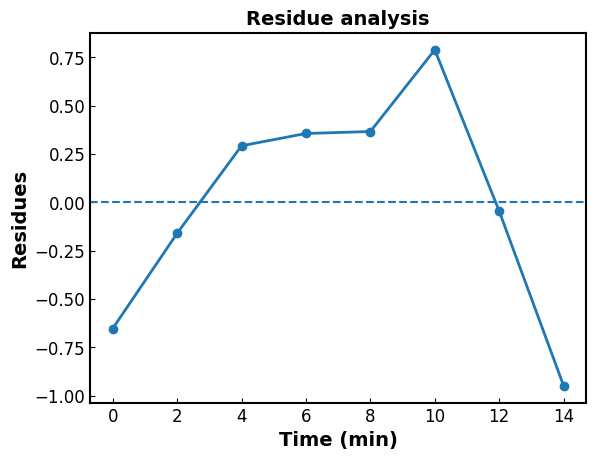

In [ ]:
# =========================
# VALIDATION USING
# REGRESSION RESIDUES
# =========================

# Residue:
# ri = yi - ŷi
#
# Where:
# ri  = residual for point i
# yi  = experimental value
# ŷi  = value calculated by the line
#
# If:
# ri > 0  → the point lies above the line
# ri < 0  → the point lies below the line


residues = log_abs - y_fit

table_residues = pd.DataFrame({
    "Time": x,
    "Experimental value": log_abs,
    "Adjusted value": y_fit,
    "Residue": residues
})

print("\nTABLE OF RESIDUES:")
print(table_residues)

# =========================
# RESIDUES PLOT
# =========================

plt.figure()

# Horizontal line at zero
plt.axhline(0,
            linestyle='--',
            linewidth=1.5)

# Residues
plt.plot(x,
         residues,
         'o-')

plt.xlabel(r'Time (min)')
plt.ylabel(r'Residues')

plt.title('Residue analysis')

#plt.grid()
plt.savefig(route_files + "residues.pdf", dpi=600, bbox_inches='tight')
plt.savefig(route_files + "residues.tif", dpi=600, bbox_inches='tight')
plt.show()